In [4]:
"""
Temperature Forecast Data Preparation
--------------------------------------

Target:
    y = T_anom(t + lead)

Dynamic predictors (lagged):
    T_anom
    ea
    pna
    nino34
    nino12
    aao
    heatcentra

Static predictors:
    lat, lon, elevation

Seasonal predictors:
    sin_month, cos_month

No modeling performed.
"""

import sqlite3
import pandas as pd
import numpy as np


# ============================================================
# CONFIGURATION
# ============================================================
path="/home/joe/work/Fire/ML/New/Data/"
ERA_DB = f"{path}era5DataMeans.db"
ERA_TABLE = "MEANS_TTdRHVPD"

CLIMATE_DB = f"{path}climate-indices.db"
CLIMATE_TABLE = "indices"

POINT_META_CSV = f"{path}latlon_elevation.csv"

# TARGET_VAR = "T"
# TARGET_VAR = "Td"
# TARGET_VAR = "RH"
TARGET_VAR = "VPD"

# TARGET_VAR = "u"

# Train climatology window
TRAIN_CLIMO_START_YM = 1990 * 12 + 1
TRAIN_CLIMO_END_YM   = 2015 * 12 + 12

# Leads
LEADS = list(range(1, 13))

# Lags applied to ALL dynamic predictors
LAG_MONTHS = [0,1,2,3,6,24]
# LAG_MONTHS = list(range(0, 7))

# Train / test split
TEST_START_YM = 2016 * 12 + 1

# 25-point mesh center
CENTER_POINT_ID = 1116
GRID_RADIUS_DEG = 0.21


# ============================================================
# LOAD ERA DATA
# ============================================================

def load_era():
    conn = sqlite3.connect(ERA_DB)
    df = pd.read_sql(f"SELECT * FROM {ERA_TABLE}", conn)
    conn.close()

    df = df.rename(columns={"Point": "point_id"})
    df["Yrmo"] = df["Yrmo"].astype(int)
    df["year"] = df["Yrmo"] // 100
    df["month"] = df["Yrmo"] % 100
    df["ym_index"] = df["year"] * 12 + df["month"]

    print(f"ERA  ", df.columns)

    return df


# ============================================================
# LOAD CLIMATE INDICES
# ============================================================

def load_indices():
    conn = sqlite3.connect(CLIMATE_DB)
    idx = pd.read_sql(f"SELECT * FROM {CLIMATE_TABLE}", conn)
    conn.close()

    idx = idx.rename(columns={
        "ea.data": "ea",
        "pna.data": "pna",
        "nino34.long.anom.data": "nino34",
        "nino12.long.anom.data": "nino12",
        "aao.data": "aao",
        "heatcentra.data": "heatcentra"
    })

    return idx


# ============================================================
# LOAD METADATA
# ============================================================

def load_metadata():
    meta = pd.read_csv(POINT_META_CSV)
    meta = meta.rename(columns={
        "point": "point_id",
        "latitude": "lat",
        "longitude": "lon",
        "elevation_m": "elevation"
    })
    return meta


# ============================================================
# MERGE DATA
# ============================================================

def merge_all():
    df = load_era()
    print("df cols:", df.columns)
    idx = load_indices()
    meta = load_metadata()

    df = df.merge(idx, left_on="Yrmo", right_on="yrmo", how="left")
    df = df.drop(columns=["yrmo"])

    df = df.merge(meta, on="point_id", how="left")

    return df


# ============================================================
# SPATIAL SUBSET (25 POINT MESH)
# ============================================================

def apply_mesh(df):
    center = df.loc[df.point_id == CENTER_POINT_ID].iloc[0]
    print(f"Center point: ID {center.point_id}, lat {center.lat:.3f}, lon {center.lon:.3f}" )
    df = df[
        (np.abs(df.lat - center.lat) <= GRID_RADIUS_DEG) &
        (np.abs(df.lon - center.lon) <= GRID_RADIUS_DEG)
    ].copy()
    print("POINTS ", df['point_id'].unique())
    return df


# ============================================================
# CLIMATOLOGY + ANOMALY
# ============================================================

def compute_climatology(df):
    mask = (
        (df.ym_index >= TRAIN_CLIMO_START_YM) &
        (df.ym_index <= TRAIN_CLIMO_END_YM)
    )

    climo = (
        df.loc[mask]
          .groupby(["point_id", "month"], as_index=False)[TARGET_VAR]
          .mean()
          .rename(columns={TARGET_VAR: "T_climo"})
    )

    return climo


def apply_anomaly(df, climo):
    df = df.merge(climo, on=["point_id", "month"], how="left")
    df["T_anom"] = df[TARGET_VAR] - df["T_climo"]
    return df


# ============================================================
# SEASONAL FEATURES
# ============================================================

def add_seasonality(df):
    df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


# ============================================================
# LAG DYNAMIC FEATURES
# ============================================================

DYNAMIC_FEATURES = [
    "T_anom",
    "ea",
    "pna",
    "nino34",
    "nino12",
    "aao",
    "heatcentra"
]


def add_lags(df):
    df = df.sort_values(["point_id", "ym_index"])

    for feature in DYNAMIC_FEATURES:
        for lag in LAG_MONTHS:
            df[f"{feature}_lag{lag}"] = (
                df.groupby("point_id")[feature].shift(lag)
            )

    return df


# ============================================================
# BUILD FORECAST TABLE
# ============================================================

def build_forecast(df):

    lagged_cols = [
        f"{feat}_lag{lag}"
        for feat in DYNAMIC_FEATURES
        for lag in LAG_MONTHS
    ]

    rows = []

    for pid, df_p in df.groupby("point_id"):
        df_p = df_p.reset_index(drop=True)

        for i, issue in df_p.iterrows():

            for lead in LEADS:

                j = i + lead
                if j >= len(df_p):
                    continue

                target = df_p.loc[j]

                row = {
                    "point_id": pid,
                    "issue_ym": issue.ym_index,
                    "lead": lead,
                    "target_ym": target.ym_index,
                    "y": target.T_anom,
                    "lat": issue.lat,
                    "lon": issue.lon,
                    "elevation": issue.elevation,
                    "sin_month": issue.sin_month,
                    "cos_month": issue.cos_month
                }
                row["issue_year"] = int(issue.year)
                row["issue_month"] = int(issue.month)

                row["target_year"] = int(target.year)
                row["target_month"] = int(target.month)




                for col in lagged_cols:
                    row[col] = issue[col]

                rows.append(row)

    forecast_df = pd.DataFrame(rows)

    forecast_df = forecast_df.dropna(subset=lagged_cols).reset_index(drop=True)

    return forecast_df, lagged_cols


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

def train_test_split(forecast_df, lagged_cols):

    feature_cols = (
        lagged_cols +
        ["lead", "lat", "lon", "elevation", "sin_month", "cos_month"]
    )

    train_df = forecast_df[forecast_df.issue_ym < TEST_START_YM].copy()
    test_df  = forecast_df[forecast_df.issue_ym >= TEST_START_YM].copy()

    X_train = train_df[feature_cols].copy()
    y_train = train_df["y"].copy()

    X_test  = test_df[feature_cols].copy()
    y_test  = test_df["y"].copy()

    return X_train, X_test, y_train, y_test, train_df, test_df


# ============================================================
# MASTER PIPELINE
# ============================================================

def prepare_dataset():

    df = merge_all()
    dfOrg = df.copy()
    df = apply_mesh(df)
    por_stats=df.groupby([ "month"])[TARGET_VAR].agg(['mean', 'std']).reset_index()

    climo = compute_climatology(df)
    df = apply_anomaly(df, climo)

    df = add_seasonality(df)
    df = add_lags(df)

    forecast_df, lagged_cols = build_forecast(df)

    return train_test_split(forecast_df, lagged_cols),por_stats,dfOrg


# ============================================================
# EXECUTE
# ============================================================

if __name__ == "__main__":

    (X_train, X_test, y_train, y_test, train_df, test_df), por_stats, dfOrg = prepare_dataset()

    print("X_train shape:", X_train.shape)
    print("X_test shape :", X_test.shape)
    print("Number of features:", X_train.shape[1])


ERA   Index(['index', 'point_id', 'Yrmo', 'Length', 'T', 'Td', 'RH', 'VPD', 'year',
       'month', 'ym_index'],
      dtype='object')
df cols: Index(['index', 'point_id', 'Yrmo', 'Length', 'T', 'Td', 'RH', 'VPD', 'year',
       'month', 'ym_index'],
      dtype='object')
Center point: ID 1116.0, lat 39.600, lon 256.100
POINTS  [ 972  973  974  975  976 1043 1044 1045 1046 1047 1114 1115 1116 1117
 1118 1185 1186 1187 1188 1189 1256 1257 1258 1259 1260]
X_train shape: (86400, 48)
X_test shape : (30450, 48)
Number of features: 48


## XGBoost by Horizon

In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np


def run_xgboost_per_lead(
    X_train,
    y_train,
    X_test,
    y_test,
    train_df,
    test_df,
    leads,
    xgb_params=None
):
    """
    Train separate XGBoost model for each lead.
    Returns MAE for train and test per lead.
    """

    if xgb_params is None:
        xgb_params = {
            "n_estimators": 500,
            "max_depth": 4,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1
        }

    results = {}

    for lead in leads:

        # Subset rows for this lead
        train_mask = train_df["lead"] == lead
        test_mask  = test_df["lead"] == lead

        X_tr = X_train[train_mask]
        y_tr = y_train[train_mask]

        X_te = X_test[test_mask]
        y_te = y_test[test_mask]

        model = XGBRegressor(**xgb_params)

        model.fit(X_tr, y_tr)

        # Predictions
        train_pred = model.predict(X_tr)
        test_pred  = model.predict(X_te)

        # Metrics
        train_mae = mean_absolute_error(y_tr, train_pred)
        test_mae  = mean_absolute_error(y_te, test_pred)

        results[lead] = {
            "train_mae": float(train_mae),
            "test_mae": float(test_mae),
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te)),
            "test_pred": test_pred.tolist(),
            "test_y": y_te.tolist()  # Store true values for test set   
        }

        print(f"Lead {lead:2d} | Train MAE: {train_mae:.4f} | Test MAE: {test_mae:.4f}")

    return results


In [19]:
results=run_xgboost_per_lead(
    X_train,
    y_train,
    X_test,
    y_test,
    train_df,
    test_df,
    range(1, 13),
    xgb_params=None
)

Lead  1 | Train MAE: 0.0600 | Test MAE: 1.7696
Lead  2 | Train MAE: 0.0639 | Test MAE: 1.7948
Lead  3 | Train MAE: 0.0677 | Test MAE: 1.6888
Lead  4 | Train MAE: 0.0583 | Test MAE: 1.8535
Lead  5 | Train MAE: 0.0687 | Test MAE: 1.8098
Lead  6 | Train MAE: 0.0744 | Test MAE: 1.8593
Lead  7 | Train MAE: 0.0670 | Test MAE: 2.0048
Lead  8 | Train MAE: 0.0675 | Test MAE: 1.8607
Lead  9 | Train MAE: 0.0757 | Test MAE: 2.0697
Lead 10 | Train MAE: 0.0681 | Test MAE: 1.9950
Lead 11 | Train MAE: 0.0588 | Test MAE: 1.9367
Lead 12 | Train MAE: 0.0562 | Test MAE: 1.8208


In [16]:
from sklearn.metrics import mean_absolute_error

def persistence_baseline(train_df, test_df):
    results = {}

    for lead in sorted(test_df.lead.unique()):

        train_mask = train_df.lead == lead
        test_mask  = test_df.lead == lead

        train_mae = mean_absolute_error(
            train_df.loc[train_mask, "y"],
            train_df.loc[train_mask, "T_anom_lag0"]
        )

        test_mae = mean_absolute_error(
            test_df.loc[test_mask, "y"],
            test_df.loc[test_mask, "T_anom_lag0"]
        )

        results[lead] = {
            "train_mae": train_mae,
            "test_mae": test_mae
        }

    return results
persistence_results = persistence_baseline(train_df, test_df)

In [23]:
import numpy as np

def lead_skill_stats(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    err = y_pred - y_true

    rmse = np.sqrt(np.mean(err**2))
    mae  = np.mean(np.abs(err))

    sigma_y = np.std(y_true, ddof=0)
    sigma_e = np.std(err, ddof=0)

    nrmse = rmse / sigma_y if sigma_y != 0 else np.nan
    ratio = sigma_e / sigma_y if sigma_y != 0 else np.nan

    # MSE skill score vs climatology (for anomalies, climo = 0)
    msess = 1 - (rmse**2 / sigma_y**2) if sigma_y != 0 else np.nan

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "sigma_y": float(sigma_y),
        "sigma_err": float(sigma_e),
        "nrmse": float(nrmse),
        "sigma_ratio": float(ratio),   # < 1 is good
        "msess": float(msess)          # > 0 is good
    }



In [24]:
for h, res in results.items():
    y_pred = res["test_pred"]
    y_true = res["test_y"]  
    r=lead_skill_stats(y_true, y_pred)
    print(h,r)
    

1 {'mae': 1.7695560444310916, 'rmse': 2.1718249649550154, 'sigma_y': 2.0617040883361484, 'sigma_err': 2.1270031490324626, 'nrmse': 1.0534125518991126, 'sigma_ratio': 1.0316723729005224, 'msess': -0.10967800449860055}
2 {'mae': 1.7947863799860189, 'rmse': 2.2372410127638207, 'sigma_y': 2.0569462564402268, 'sigma_err': 2.1989994500928427, 'nrmse': 1.0876516611744704, 'sigma_ratio': 1.0690602358753187, 'msess': -0.1829861360555849}
3 {'mae': 1.688813354435748, 'rmse': 2.116060875953786, 'sigma_y': 2.054647283457568, 'sigma_err': 2.062203264288341, 'nrmse': 1.029890090134045, 'sigma_ratio': 1.0036775075175228, 'msess': -0.06067359775631176}
4 {'mae': 1.8534698355948371, 'rmse': 2.2531078100208237, 'sigma_y': 2.0641983982299217, 'sigma_err': 2.2229047156115658, 'nrmse': 1.0915170808934327, 'sigma_ratio': 1.0768852051807312, 'msess': -0.19140953788212056}
5 {'mae': 1.8098243911867582, 'rmse': 2.2315280942917335, 'sigma_y': 2.0645119103130787, 'sigma_err': 2.2185478066973126, 'nrmse': 1.08089

## Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np


def run_linear_per_lead(
    X_train,
    y_train,
    X_test,
    y_test,
    train_df,
    test_df,
    leads
):
    results = {}

    for lead in leads:

        train_mask = train_df["lead"] == lead
        test_mask  = test_df["lead"] == lead

        X_tr = X_train.loc[train_mask]
        y_tr = y_train.loc[train_mask]

        X_te = X_test.loc[test_mask]
        y_te = y_test.loc[test_mask]

        model = LinearRegression()
        model.fit(X_tr, y_tr)

        train_pred = model.predict(X_tr)
        test_pred  = model.predict(X_te)

        # Errors
        err = test_pred - y_te

        mae  = mean_absolute_error(y_te, test_pred)
        rmse = np.sqrt(np.mean(err**2))

        sigma_y = np.std(y_te, ddof=0)
        sigma_e = np.std(err, ddof=0)

        nrmse = rmse / sigma_y if sigma_y != 0 else np.nan
        sigma_ratio = sigma_e / sigma_y if sigma_y != 0 else np.nan
        msess = 1 - (rmse**2 / sigma_y**2) if sigma_y != 0 else np.nan

        results[lead] = {
            "mae": float(mae),
            "rmse": float(rmse),
            "sigma_y": float(sigma_y),
            "sigma_err": float(sigma_e),
            "nrmse": float(nrmse),
            "sigma_ratio": float(sigma_ratio),
            "msess": float(msess)
        }

        print(
            f"Lead {lead:2d} | "
            f"MAE: {mae:.3f} | "
            f"NRMSE: {nrmse:.3f} | "
            f"MSESS: {msess:.3f}"
        )

    return results
linear_results = run_linear_per_lead(
    X_train,
    y_train,
    X_test,
    y_test,
    train_df,
    test_df,
    range(1, 13)
)


Lead  1 | MAE: 1.725 | NRMSE: 1.041 | MSESS: -0.083
Lead  2 | MAE: 1.796 | NRMSE: 1.066 | MSESS: -0.136
Lead  3 | MAE: 1.766 | NRMSE: 1.042 | MSESS: -0.085
Lead  4 | MAE: 1.883 | NRMSE: 1.115 | MSESS: -0.243
Lead  5 | MAE: 1.860 | NRMSE: 1.136 | MSESS: -0.290
Lead  6 | MAE: 1.871 | NRMSE: 1.177 | MSESS: -0.385
Lead  7 | MAE: 1.819 | NRMSE: 1.119 | MSESS: -0.252
Lead  8 | MAE: 1.857 | NRMSE: 1.098 | MSESS: -0.206
Lead  9 | MAE: 1.837 | NRMSE: 1.087 | MSESS: -0.181
Lead 10 | MAE: 1.808 | NRMSE: 1.085 | MSESS: -0.178
Lead 11 | MAE: 1.780 | NRMSE: 1.072 | MSESS: -0.150
Lead 12 | MAE: 1.792 | NRMSE: 1.070 | MSESS: -0.144


## XGBoost by Month

In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error


def skill_stats(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    err = y_pred - y_true

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean(err**2))
    sigma_y = np.std(y_true, ddof=0)
    msess = 1 - (rmse**2 / sigma_y**2) if sigma_y != 0 else np.nan

    return mae, rmse, msess


def run_month_loop(
    X_train, y_train,
    X_test, y_test,
    train_df, test_df
):

    results = {}

    for month in range(1, 13):

        train_mask = train_df["target_month"] == month
        test_mask  = test_df["target_month"] == month

        if train_mask.sum() < 200 or test_mask.sum() < 100:
            continue

        X_tr = X_train.loc[train_mask]
        y_tr = y_train.loc[train_mask]

        X_te = X_test.loc[test_mask]
        y_te = y_test.loc[test_mask]


        xgb_params = {
            "n_estimators": 1200,
            "max_depth": 10,              # shallower trees
            "learning_rate": 0.02,       # slower learning
            "subsample": 0.7,            # inject noise robustness
            "colsample_bytree": 0.7,
            "min_child_weight": 5,       # prevent small splits
            "reg_lambda": 5.0,           # L2 regularization
            "gamma": 0.2,                # require loss reduction
            "random_state": 42,
            "n_jobs": -1
        }


        # xgb_params = {
        #       "n_estimators": 800,
        #     "max_depth": 3,
        #     "learning_rate": 0.03,
        #     "subsample": 0.8,
        #     "colsample_bytree": 0.8,
        #     "reg_lambda": 2.0,
        #     "random_state": 42,
        #     "n_jobs": -1
        # }


        model = XGBRegressor(**xgb_params)



        # model = XGBRegressor(
        #     n_estimators=800,
        #     max_depth=3,
        #     learning_rate=0.03,
        #     subsample=0.8,
        #     colsample_bytree=0.8,
        #     reg_lambda=2.0,
        #     random_state=42,
        #     n_jobs=-1
        # )








        model.fit(X_tr, y_tr)

        train_pred = model.predict(X_tr)
        test_pred  = model.predict(X_te)

        train_mae, train_rmse, train_msess = skill_stats(y_tr, train_pred)
        test_mae,  test_rmse,  test_msess  = skill_stats(y_te, test_pred)

        results[month] = {
            "train_mae": float(train_mae),
            "test_mae": float(test_mae),
            "test_msess": float(test_msess),
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te))
        }

        print(
            f"Month {month:02d} , "
            f"Test MAE {test_mae:.3f} , "
            f"MSESS {test_msess:.3f}"
        )

    return results,xgb_params

results_month_loop2, xgb_params = run_month_loop(
    X_train, y_train,
    X_test, y_test,
    train_df, test_df
)

results_month_loop = results_month_loop1
old=0
new=0
for month in results_month_loop.keys():
    por_std = a.loc[a.month == month, 'std'].values[0]
    mae=results_month_loop[month]['test_mae']
    maeN=results_month_loop2[month]['test_mae']
    norm = mae / por_std if por_std != 0 else np.nan
    normN = maeN / por_std if por_std != 0 else np.nan
    print(f"Month {month:02d}: diff: {normN/ norm:.3f}  mae_norm_std_old:{norm:.3f}  mae_norm_std_new:{normN:.3f}  mae_old:{results_month_loop[month]['test_mae']:.3f}  mae_new:{results_month_loop2[month]['test_mae']:.3f}  por_std: {por_std:.3f}")
    old += mae
    new += maeN


print(f"Mean old MAE: {old/12:.3f}")
print(f"Mean new MAE: {new/12:.3f}")
print("XGBoost parameters used:")
for param, value in xgb_params.items():
    print(f"  {param}: {value}")

with open("xgb_results.txt", "a") as f:
    f.write("XGBoost parameters used:\n")
    for param, value in xgb_params.items():
        f.write(f"  {param:20.20s}: {value}\n")
    f.write(f"Mean old MAE: {old/12:.3f}\n")
    f.write(f"Mean new MAE: {new/12:.3f}\n")    
    f.write("-----------------")

Month 01 | Test MAE 1.862 | MSESS -0.239
Month 02 | Test MAE 2.063 | MSESS -0.189
Month 03 | Test MAE 2.035 | MSESS -0.346
Month 04 | Test MAE 1.112 | MSESS -1.567
Month 05 | Test MAE 1.357 | MSESS 0.014
Month 06 | Test MAE 1.972 | MSESS -0.731
Month 07 | Test MAE 0.997 | MSESS -1.459
Month 08 | Test MAE 1.097 | MSESS -0.532
Month 09 | Test MAE 2.126 | MSESS -4.888
Month 10 | Test MAE 2.055 | MSESS -0.039
Month 11 | Test MAE 2.592 | MSESS -0.480
Month 12 | Test MAE 2.556 | MSESS -1.176
Month 01: diff: 1.013  mae_norm_std_old:0.403  mae_norm_std_new:0.408  mae_old:1.839  mae_new:1.862  por_std: 4.560
Month 02: diff: 0.910  mae_norm_std_old:0.484  mae_norm_std_new:0.441  mae_old:2.266  mae_new:2.063  por_std: 4.677
Month 03: diff: 0.942  mae_norm_std_old:0.435  mae_norm_std_new:0.410  mae_old:2.159  mae_new:2.035  por_std: 4.961
Month 04: diff: 0.874  mae_norm_std_old:0.245  mae_norm_std_new:0.214  mae_old:1.273  mae_new:1.112  por_std: 5.189
Month 05: diff: 0.921  mae_norm_std_old:0.280

In [109]:
results_month_loopB = results_month_loop2.copy()

## Analysis

In [91]:
a=df.groupby([ "month"])[TARGET_VAR].agg(['mean', 'std']).reset_index()

In [94]:
results_month_loop = results_month_loop1

for month in results_month_loop.keys():
    por_std = a.loc[a.month == month, 'std'].values[0]
    mae=results_month_loop[month]['test_mae']
    maeN=results_month_loop2[month]['test_mae']
    norm = mae / por_std if por_std != 0 else np.nan
    normN = maeN / por_std if por_std != 0 else np.nan
    print(f"Month {month:02d}: diff: {normN/ norm:.3f}  mae_norm_std_old:{norm:.3f}  mae_norm_std_new:{normN:.3f}  mae_old:{results_month_loop[month]['test_mae']:.3f}  mae_new:{results_month_loop2[month]['test_mae']:.3f}  por_std: {por_std:.3f}")

Month 01: diff: 0.995  mae_norm_std_old:0.403  mae_norm_std_new:0.401  mae_old:1.839  mae_new:1.830  por_std: 4.560
Month 02: diff: 0.979  mae_norm_std_old:0.484  mae_norm_std_new:0.474  mae_old:2.266  mae_new:2.218  por_std: 4.677
Month 03: diff: 0.959  mae_norm_std_old:0.435  mae_norm_std_new:0.417  mae_old:2.159  mae_new:2.071  por_std: 4.961
Month 04: diff: 0.916  mae_norm_std_old:0.245  mae_norm_std_new:0.225  mae_old:1.273  mae_new:1.166  por_std: 5.189
Month 05: diff: 0.975  mae_norm_std_old:0.280  mae_norm_std_new:0.273  mae_old:1.473  mae_new:1.436  por_std: 5.266
Month 06: diff: 0.971  mae_norm_std_old:0.388  mae_norm_std_new:0.376  mae_old:1.978  mae_new:1.920  por_std: 5.101
Month 07: diff: 0.949  mae_norm_std_old:0.225  mae_norm_std_new:0.214  mae_old:1.054  mae_new:1.000  por_std: 4.675
Month 08: diff: 1.015  mae_norm_std_old:0.234  mae_norm_std_new:0.238  mae_old:1.079  mae_new:1.095  por_std: 4.607
Month 09: diff: 1.008  mae_norm_std_old:0.416  mae_norm_std_new:0.419  m

In [25]:
df['point_id'].unique()

array([ 68,  69,  70, 139, 140, 141, 210, 211, 212])

In [28]:
a

,month,mean,std
0,1,-1.749177,2.011247
1,2,-0.480671,2.794954
2,3,4.724726,2.444548
3,4,9.359280,1.646661
4,5,15.011360,1.628952
5,6,21.350805,1.991458
6,7,24.566847,1.584382
7,8,23.446339,1.420432
8,9,19.163952,1.845313
9,10,11.175596,1.951461


## Neural Network

In [5]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping


def run_nn_month_loop(
    X_train, y_train,
    X_test, y_test,
    train_df, test_df,
    por_std_by_month
):

    results = {}

    for month in range(1, 13):

        train_mask = train_df["target_month"] == month
        test_mask  = test_df["target_month"] == month

        if train_mask.sum() < 300 or test_mask.sum() < 100:
            continue

        # Slice data
        X_tr = X_train.loc[train_mask].values
        y_tr = y_train.loc[train_mask].values

        X_te = X_test.loc[test_mask].values
        y_te = y_test.loc[test_mask].values

        # Scale features
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        # Build model inline
        model = tf.keras.Sequential([
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005),
            input_shape=(X_tr.shape[1],)
        ),
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005)
        ),
        layers.Dense(1)
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
            loss="mae"
        
        )


        # Predict
        preds = model.predict(X_te,verbose=0).flatten()

        mae = np.mean(np.abs(preds - y_te))
        mae_norm_std = mae / por_std_by_month[month]['std']

        results[month] = {
            "mae": float(mae),
            "mae_norm_std": float(mae_norm_std),
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te))
        }

        print(
            f"Month {month:02d} , "
            f"MAE {mae:.3f} | "
            f"MAE/STD {mae_norm_std:.3f}"
        )
    return results, model

por_stats_dict = {
    int(row['month']): {'mean': row['mean'], 'std': row['std']}
    for _, row in por_stats.iterrows()
}

vv=3
nn_results_month_loop,model = run_nn_month_loop(
    X_train, y_train,
    X_test, y_test,
    train_df, test_df,      
    por_stats_dict
)   
model.save(f"nn_month_loop_model_{vv}.h5")
pd.DataFrame(nn_results_month_loop).T.to_csv(f"nn_month_loop_results_{vv}.csv", index_label="month")


/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Month 01 , MAE 0.395 | MAE/STD 4.207


/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Month 02 , MAE 0.445 | MAE/STD 4.139


/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Month 10 , MAE 0.399 | MAE/STD 2.019


/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Month 11 , MAE 0.435 | MAE/STD 2.793


/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Month 12 , MAE 0.381 | MAE/STD 3.983


In [27]:
por_stats_dict

{1: {'mean': np.float64(55.29146760368664),
  'std': np.float64(8.443398162517852)},
 2: {'mean': np.float64(52.99242962350458),
  'std': np.float64(8.210119514763946)},
 3: {'mean': np.float64(50.30718041474654),
  'std': np.float64(7.807170020111151)},
 4: {'mean': np.float64(49.17750019047619),
  'std': np.float64(7.0796183053157735)},
 5: {'mean': np.float64(53.09298451612903),
  'std': np.float64(7.811013850701937)},
 6: {'mean': np.float64(48.24144314285714),
  'std': np.float64(8.231326597379084)},
 7: {'mean': np.float64(48.10428741935483),
  'std': np.float64(6.033330125071756)},
 8: {'mean': np.float64(49.76008423963133),
  'std': np.float64(6.133252174918398)},
 9: {'mean': np.float64(45.926667095238095),
  'std': np.float64(6.464260289665942)},
 10: {'mean': np.float64(48.99307834101383),
  'std': np.float64(7.588896235848609)},
 11: {'mean': np.float64(52.302722857142854),
  'std': np.float64(8.783156444985712)},
 12: {'mean': np.float64(53.948920715148724),
  'std': np.fl

<Axes: >

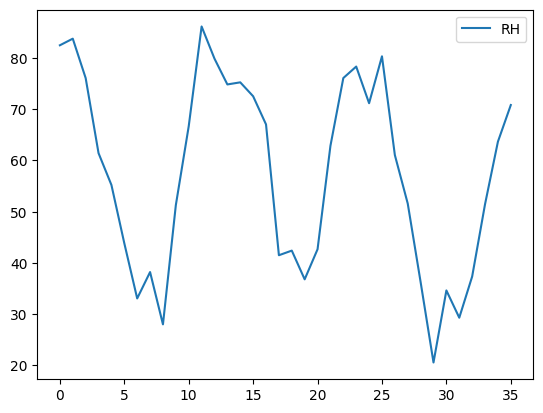

In [29]:
a=dfOrg.loc[(dfOrg['point_id'] == 0) & (dfOrg['year'] >= 2010) & (dfOrg['year'] <= 2012)].reset_index(drop=True)
a.plot( y=["RH"])

In [6]:
import os


jja=0
djf=0
mam=0
son=0
fout=open(f"nn_month_loop_results_{TARGET_VAR}.txt", "w" )
for mo,dct in nn_results_month_loop.items():
    print(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}") 
    fout.write(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}\n")
    if mo in [6,7,8]:
        jja += dct['mae_norm_std']

    if mo in [12,1,2]:
        djf += dct['mae_norm_std']  
    
    if mo in [3,4,5]:
        mam += dct['mae_norm_std']
    
    if mo in [9,10,11]:
        son += dct['mae_norm_std']
fout.close()


print(f"JJA avg MAE/STD: {jja/3:.3f}")
print(f"DJF avg MAE/STD: {djf/3:.3f}")
print(f"MAM avg MAE/STD: {mam/3:.3f}")
print(f"SON avg MAE/STD: {son/3:.3f}")
fout = open(f"nn_month_loop_results_summary.txt", "a")
if not os.path.exists("nn_month_loop_results_summary.txt"):
    fout.write("target_var,jja_mae_norm_std,djf_mae_norm_std,mam_mae_norm_std,son_mae_norm_std\n")
fout.write(f"{TARGET_VAR},{jja/3:.3f},{djf/3:.3f},{mam/3:.3f},{son/3:.3f}\n")
fout.close()

Month 01 | MAE: 0.395 | MAE/STD: 4.207
Month 02 | MAE: 0.445 | MAE/STD: 4.139
Month 03 | MAE: 0.557 | MAE/STD: 3.789
Month 04 | MAE: 1.046 | MAE/STD: 6.804
Month 05 | MAE: 0.361 | MAE/STD: 1.580
Month 06 | MAE: 0.512 | MAE/STD: 1.309
Month 07 | MAE: 0.365 | MAE/STD: 1.168
Month 08 | MAE: 0.654 | MAE/STD: 2.228
Month 09 | MAE: 0.323 | MAE/STD: 1.161
Month 10 | MAE: 0.399 | MAE/STD: 2.019
Month 11 | MAE: 0.435 | MAE/STD: 2.793
Month 12 | MAE: 0.381 | MAE/STD: 3.983
JJA avg MAE/STD: 1.568
DJF avg MAE/STD: 4.110
MAM avg MAE/STD: 4.058
SON avg MAE/STD: 1.991


In [22]:
dd = pd.read_csv("por_baseline_mae_by_month_lags_3_24.csv")
stats={}
for col in dd.columns:
    if col != "month":
        jja = dd.loc[dd.month.isin([6,7,8]), col].mean()
        djf = dd.loc[dd.month.isin([12,1,2]), col].mean()
        mam = dd.loc[dd.month.isin([3,4,5]), col].mean()
        son = dd.loc[dd.month.isin([9,10,11]), col].mean()

        stats[col] = {
            "JJA": jja,
            "DJF": djf,
            "MAM": mam,
            "SON": son
        }
stats 

{'lag3': {'JJA': np.float64(0.8686666666666666),
  'DJF': np.float64(0.9696666666666666),
  'MAM': np.float64(0.8293333333333335),
  'SON': np.float64(1.0663333333333334)},
 'lag6': {'JJA': np.float64(0.876),
  'DJF': np.float64(0.9556666666666667),
  'MAM': np.float64(0.848),
  'SON': np.float64(1.0813333333333333)},
 'lag12': {'JJA': np.float64(0.9033333333333333),
  'DJF': np.float64(1.083),
  'MAM': np.float64(0.907),
  'SON': np.float64(1.1336666666666666)},
 'lag24': {'JJA': np.float64(0.8566666666666666),
  'DJF': np.float64(0.9440000000000001),
  'MAM': np.float64(0.8466666666666667),
  'SON': np.float64(1.0453333333333334)}}

In [27]:
jja=0
djf=0
mam=0
son=0

for mo,dct in nn_results_month_loop.items():
    print(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}") 
    if mo in [6,7,8]:
        jja += dct['mae_norm_std']

    if mo in [12,1,2]:
        djf += dct['mae_norm_std']  
    
    if mo in [3,4,5]:
        mam += dct['mae_norm_std']
    
    if mo in [9,10,11]:
        son += dct['mae_norm_std']

print(f"JJA avg MAE/STD: {jja/3:.3f}")
print(f"DJF avg MAE/STD: {djf/3:.3f}")
print(f"MAM avg MAE/STD: {mam/3:.3f}")
print(f"SON avg MAE/STD: {son/3:.3f}")

stats['NEW'] = {"JJA":jja/3, "DJF":djf/3, "MAM":mam/3, "SON":son/3}
fout = open(f"seasonal_skill_comparison_{TARGET_VAR}.csv", "w")
fout.write("Model,Season,JJA_MAE_STD,DJF_MAE_STD,MAM_MAE_STD,SON_MAE_STD\n")
for k,d in stats.items():
    fout.write(f"{k:6s} , {d['JJA']:.3f} , {d['DJF']:.3f} , {d['MAM']:.3f} , {d['SON']:.3f}\n")
fout.close()

Month 01 | MAE: 1.994 | MAE/STD: 0.853
Month 02 | MAE: 2.216 | MAE/STD: 1.009
Month 03 | MAE: 1.756 | MAE/STD: 0.861
Month 04 | MAE: 0.977 | MAE/STD: 0.555
Month 05 | MAE: 1.475 | MAE/STD: 0.878
Month 06 | MAE: 1.724 | MAE/STD: 0.858
Month 07 | MAE: 0.906 | MAE/STD: 0.620
Month 08 | MAE: 1.060 | MAE/STD: 0.736
Month 09 | MAE: 2.443 | MAE/STD: 1.314
Month 10 | MAE: 2.156 | MAE/STD: 1.070
Month 11 | MAE: 2.577 | MAE/STD: 0.990
Month 12 | MAE: 2.122 | MAE/STD: 0.955
JJA avg MAE/STD: 0.738
DJF avg MAE/STD: 0.939
MAM avg MAE/STD: 0.765
SON avg MAE/STD: 1.124


In [24]:
print(f'   NEW  {stats["NEW"]["JJA"]:<6.3f}  {stats["NEW"]["DJF"]:<6.3f}  {stats["NEW"]["MAM"]:<6.3f}  {stats["NEW"]["SON"]:<6.3f}')
print(f'  LAG3  {stats["lag3"]["JJA"]:<6.3f}  {stats["lag3"]["DJF"]:<6.3f}  {stats["lag3"]["MAM"]:<6.3f}  {stats["lag3"]["SON"]:<6.3f}')
print(f'  LAG6  {stats["lag6"]["JJA"]:<6.3f}  {stats["lag6"]["DJF"]:<6.3f}  {stats["lag6"]["MAM"]:<6.3f}  {stats["lag6"]["SON"]:<6.3f}')
print(f' LAG12  {stats["lag12"]["JJA"]:<6.3f}  {stats["lag12"]["DJF"]:<6.3f}  {stats["lag12"]["MAM"]:<6.3f}  {stats["lag12"]["SON"]:<6.3f}')
print(f' LAG24  {stats["lag24"]["JJA"]:<6.3f}  {stats["lag24"]["DJF"]:<6.3f}  {stats["lag24"]["MAM"]:<6.3f}  {stats["lag24"]["SON"]:<6.3f}')

   NEW  0.738   0.939   0.765   1.124 
  LAG3  0.869   0.970   0.829   1.066 
  LAG6  0.876   0.956   0.848   1.081 
 LAG12  0.903   1.083   0.907   1.134 
 LAG24  0.857   0.944   0.847   1.045 


| Month | lag3  | lag6  | lag12 | lag24 |
| ----- | ----- | ----- | ----- | ----- |
| 1     | 0.747 | 0.800 | 0.793 | 0.787 |
| 2     | 0.982 | 0.887 | 1.017 | 0.925 |
| 3     | 0.996 | 0.883 | 0.926 | 1.003 |
| 4     | 0.680 | 0.814 | 0.736 | 0.626 |
| 5     | 0.812 | 0.847 | 1.059 | 0.911 |
| 6     | 1.015 | 1.159 | 0.965 | 1.097 |
| 7     | 0.690 | 0.697 | 0.944 | 0.653 |
| 8     | 0.901 | 0.772 | 0.801 | 0.820 |
| 9     | 1.228 | 1.247 | 1.431 | 1.066 |
| 10    | 1.016 | 1.003 | 1.029 | 1.080 |
| 11    | 0.955 | 0.994 | 0.941 | 0.990 |
| 12    | 1.180 | 1.180 | 1.439 | 1.120 |


In [10]:
dd.to_csv("por_baseline_mae_by_month_lags_3_24.csv", index=False)